In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from itertools import product as iproduct

# SARIMAX — Previsão de PM2.5 em São Paulo (2013–2019)

**Projeto:** Respira SP  
**Modelo:** SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous variables)  
**Estratégia de dados:** interpolação temporal em gaps ≤ 12h + imputação sazonal em gaps maiores  
**Período:** Janeiro 2013 → Dezembro 2019  
**Split:** Treino 2013–2017 | Validação 2018 | Teste 2019  

> **Nota:** A colega Izabel está trabalhando no modelo 2016–2019. Este notebook cobre o período completo 2013–2019, utilizando a estratégia de dados:interpolação temporal em gaps ≤ 12h + imputação sazonal em gaps maiores   como baseline de dados.

# Estilo

In [65]:
plt.style.use('dark_background')
ACCENT  = '#00C4CC'
ACCENT2 = '#FF6B6B'
ACCENT3 = '#FFD93D'
FIG_SIZE = (16, 5)

In [66]:
DATA_PATH = "../data/data_interpolacao_gaps_maiores_medias/pm25_2013_2019_interp_12h_media_sazonal_all_features.csv"
TARGET    = 'MP2.5'
EXOG_COLS = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']

## 1. Carregamento 

In [96]:
df = pd.read_csv(DATA_PATH, index_col='time', parse_dates=True)
df.index = df.index.tz_localize(None)  # remover timezone para compatibilidade com statsmodels
df = df.sort_index()
print(f'Período : {df.index.min()} → {df.index.max()}')
print(f'Shape   : {df.shape}  ({df.shape[0]:,} linhas x {df.shape[1]} colunas)')
print(f'NaN em MP2.5: {df[TARGET].isnull().sum()}')
print()
df.head()

Período : 2013-05-09 03:00:00 → 2019-08-18 02:00:00
Shape   : (55008, 9)  (55,008 linhas x 9 colunas)
NaN em MP2.5: 0



,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media
time,,,,,,,,,
2013-05-09 03:00:00,26.0,10.301001,91.648320,0.0,7.421590,5,3,3,0
2013-05-09 04:00:00,21.0,9.751000,92.548310,0.0,7.993298,5,4,3,0
2013-05-09 05:00:00,20.0,9.401000,92.528390,0.0,7.928178,5,5,3,0
2013-05-09 06:00:00,18.0,9.251000,92.519806,0.0,7.280550,5,6,3,0
2013-05-09 07:00:00,20.0,9.851000,91.310250,0.0,6.287130,5,7,3,0


In [ ]:
# completude = (1 - df.isnull().mean()) * 100
# print('Completude por coluna (%):')
# print(completude.round(2).to_string())

Completude por coluna (%):
MP2.5                   100.0
temperature_2m          100.0
relative_humidity_2m    100.0
precipitation           100.0
wind_speed_10m          100.0
mes                     100.0
hora                    100.0
dia_semana              100.0
MP2.5_imputado_media    100.0


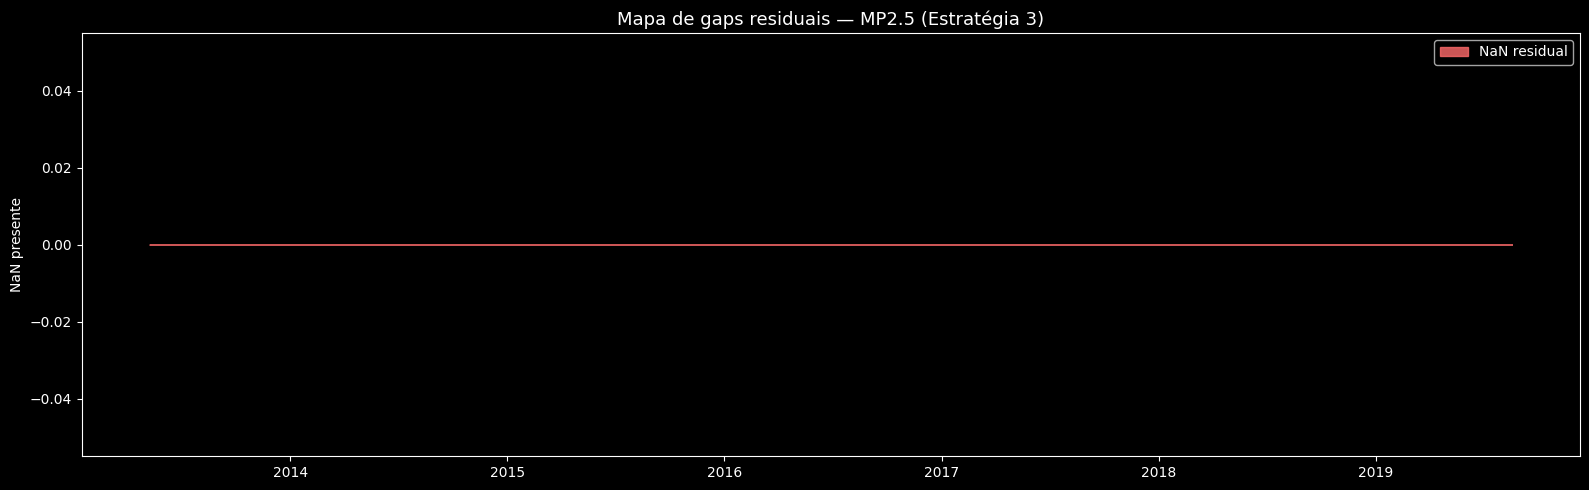

Total de NaN em MP2.5: 0


In [97]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
nan_mask = df[TARGET].isnull().astype(int)
ax.fill_between(df.index, nan_mask, color=ACCENT2, alpha=0.8, label='NaN residual')
ax.set_title('Mapa de gaps residuais — MP2.5 (Estratégia 3)', fontsize=13)
ax.set_ylabel('NaN presente')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Total de NaN em MP2.5: {df[TARGET].isnull().sum()}')

## 2. Análise Exploratória

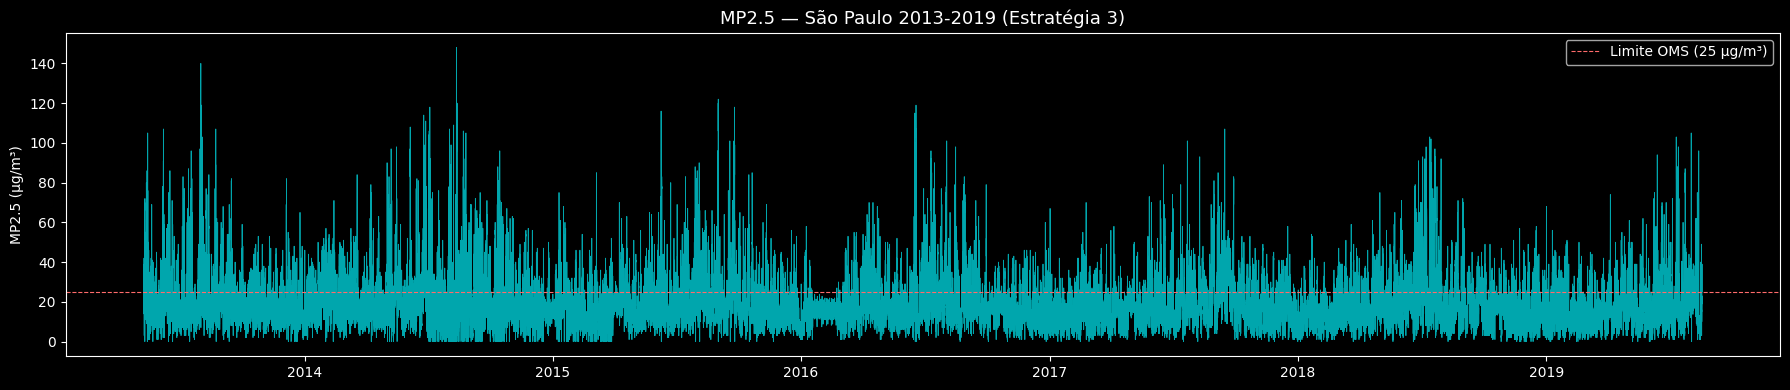

In [98]:
#Série temporal completa 2013-2019
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df.index, df[TARGET], color=ACCENT, linewidth=0.6, alpha=0.85)
ax.axhline(25, color=ACCENT2, linestyle='--', linewidth=0.8, label='Limite OMS (25 µg/m³)')
ax.set_title('MP2.5 — São Paulo 2013-2019 (Estratégia 3)', fontsize=13)
ax.set_ylabel('MP2.5 (µg/m³)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

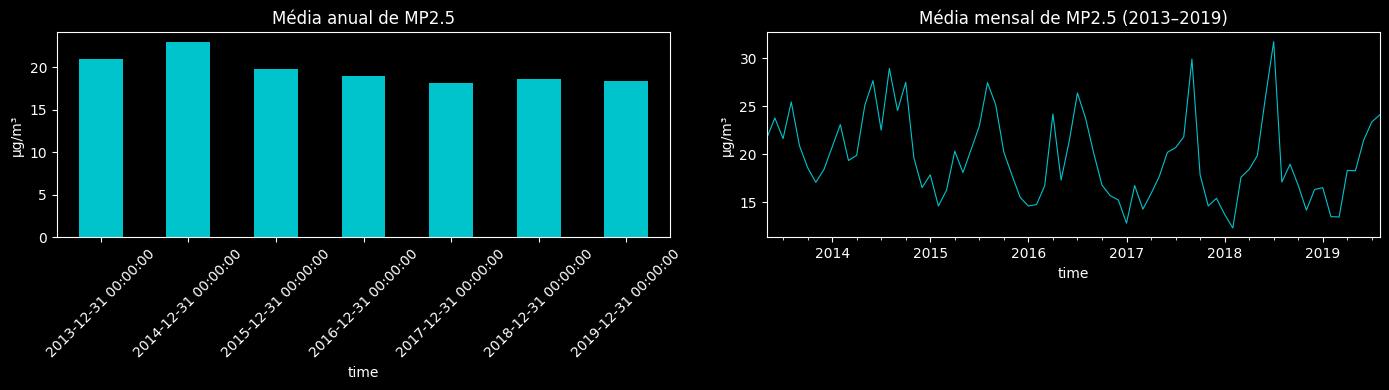

In [99]:
#Médias por ano e por mês
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[TARGET].resample('Y').mean().plot(kind='bar', ax=axes[0], color=ACCENT)
axes[0].set_title('Média anual de MP2.5')
axes[0].set_ylabel('µg/m³')
axes[0].tick_params(axis='x', rotation=45)

df[TARGET].resample('ME').mean().plot(ax=axes[1], color=ACCENT, linewidth=0.8)
axes[1].set_title('Média mensal de MP2.5 (2013–2019)')
axes[1].set_ylabel('µg/m³')

plt.tight_layout()
plt.show()

In [101]:
# # Heatmap hora × mês
# # Usar colunas 'hora' e 'mes' que já existem no dataset
# pivot = df.groupby(['hora', 'mes'])[TARGET].mean().unstack()

# fig, ax = plt.subplots(figsize=(12, 6))
# sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3, linecolor='#222')
# ax.set_title('MP2.5 médio por Hora × Mês', fontsize=13)
# ax.set_xlabel('Mês')
# ax.set_ylabel('Hora do dia')
# ax.set_xticklabels(['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
# plt.tight_layout()
# plt.show()

## 3. Teste de Estacionariedade (ADF)

In [102]:
def adf_report(serie, label='Série'):
    result = adfuller(serie.dropna())
    estacionaria = result[1] < 0.05
    print(f'\n── ADF: {label} ────────────────────────────')
    print(f'  Estatística ADF : {result[0]:.4f}')
    print(f'  p-value         : {result[1]:.4f}')
    print(f'  Valores críticos: {result[4]}')
    print(f'  ➜ {"ESTACIONÁRIA" if estacionaria else " NÃO estacionária"} (α=0.05)')
    return estacionaria

serie_full = df[TARGET].dropna()
estac = adf_report(serie_full, 'MP2.5 original')


── ADF: MP2.5 original ────────────────────────────
  Estatística ADF : -20.0795
  p-value         : 0.0000
  Valores críticos: {'1%': -3.430469012275193, '5%': -2.861592601085853, '10%': -2.5667979978001445}
  ➜ ESTACIONÁRIA (α=0.05)


In [103]:
if not estac:
    serie_diff1 = serie_full.diff().dropna()
    adf_report(serie_diff1, 'MP2.5 — 1ª diferença')
    d_value = 1
else:
    d_value = 0

print(f'\n➜ Parâmetro d escolhido: {d_value}')


➜ Parâmetro d escolhido: 0


## 4. ACF e PACF — Identificação de p, q, P, Q

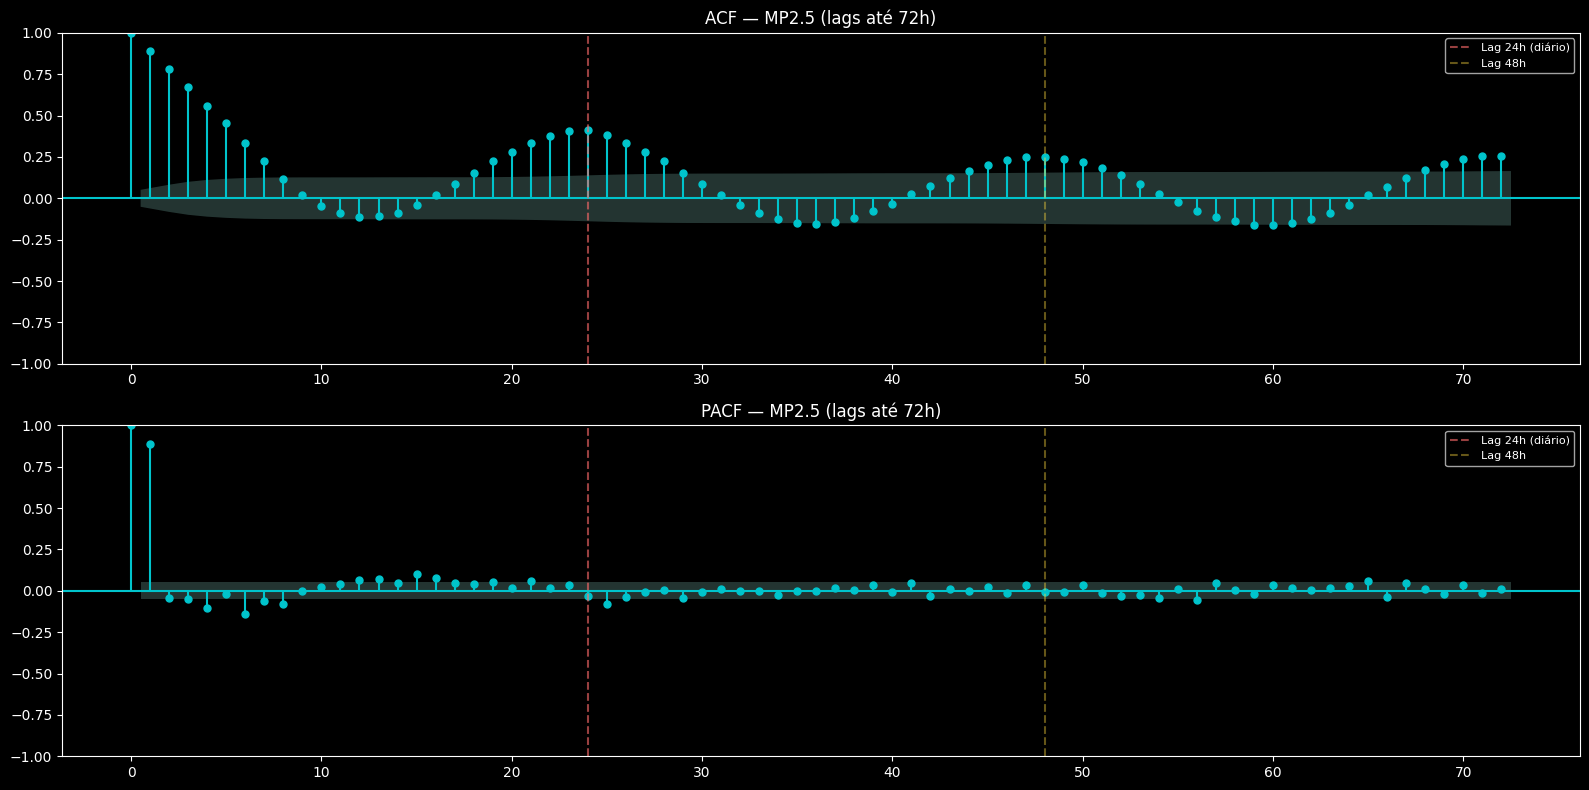


📖 Leitura:
  - Pico no lag 24 → sazonalidade diária confirmada (s=24)
  - ACF decaindo lentamente → componente AR
  - PACF corte abrupto → sugere p=1 ou p=2
  - Picos nos lags 24, 48 no ACF sazonal → Q ≥ 1



In [104]:
# Usar 2 meses de 2018 (limpo) para visualização
serie_acf = df.loc['2018-06':'2018-07', TARGET].dropna()
if d_value == 1:
    serie_acf = serie_acf.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(serie_acf, lags=72, ax=axes[0],
         title='ACF — MP2.5 (lags até 72h)',
         color=ACCENT, vlines_kwargs={'colors': ACCENT})

plot_pacf(serie_acf, lags=72, ax=axes[1],
          title='PACF — MP2.5 (lags até 72h)',
          color=ACCENT, vlines_kwargs={'colors': ACCENT})

for ax in axes:
    ax.axvline(24,  color=ACCENT2, linestyle='--', alpha=0.6, label='Lag 24h (diário)')
    ax.axvline(48,  color=ACCENT3, linestyle='--', alpha=0.4, label='Lag 48h')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('''
📖 Leitura:
  - Pico no lag 24 → sazonalidade diária confirmada (s=24)
  - ACF decaindo lentamente → componente AR
  - PACF corte abrupto → sugere p=1 ou p=2
  - Picos nos lags 24, 48 no ACF sazonal → Q ≥ 1
''')

## 5. Split Temporal

🔵 Treino    : 2013-05-09 03:00:00 → 2017-12-31 23:00:00 (40,749 registos)
🟡 Validação : 2018-01-01 00:00:00 → 2018-12-31 23:00:00 (8,760 registos)
🔴 Teste     : 2019-01-01 00:00:00 → 2019-08-18 02:00:00 (5,499 registos)


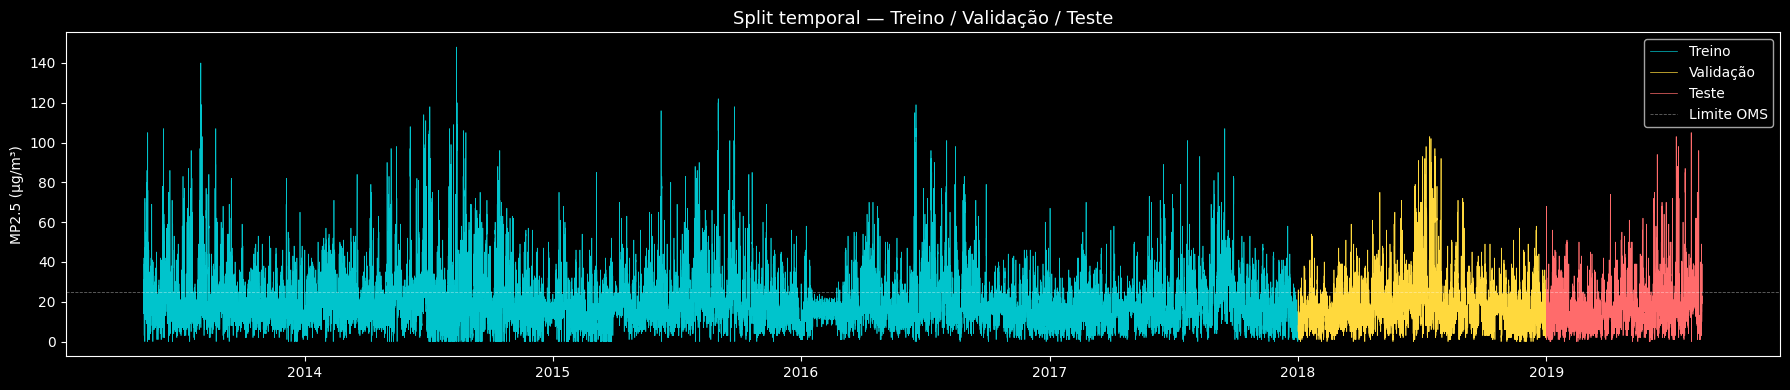

In [26]:
TRAIN_END = '2017-12-31 23:00'
VAL_END   = '2018-12-31 23:00'

train = df.loc[:TRAIN_END].copy()
val   = df.loc['2018-01-01':VAL_END].copy()
test  = df.loc['2019-01-01':].copy()

print(f'🔵 Treino    : {train.index.min()} → {train.index.max()} ({len(train):,} registos)')
print(f'🟡 Validação : {val.index.min()} → {val.index.max()} ({len(val):,} registos)')
print(f'🔴 Teste     : {test.index.min()} → {test.index.max()} ({len(test):,} registos)')

# ── Visualização do split ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(train.index, train[TARGET], color=ACCENT,  linewidth=0.5, label='Treino')
ax.plot(val.index,   val[TARGET],   color=ACCENT3, linewidth=0.5, label='Validação')
ax.plot(test.index,  test[TARGET],  color=ACCENT2, linewidth=0.5, label='Teste')
ax.axhline(25, color='white', linestyle='--', linewidth=0.6, alpha=0.4, label='Limite OMS')
ax.set_title('Split temporal — Treino / Validação / Teste', fontsize=13)
ax.set_ylabel('MP2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Preparar y e X
y_train = train[TARGET].dropna()
y_val   = val[TARGET].dropna()
y_test  = test[TARGET].dropna()

X_train = train[EXOG_COLS].loc[y_train.index].ffill()
X_val   = val[EXOG_COLS].loc[y_val.index].ffill()
X_test  = test[EXOG_COLS].loc[y_test.index].ffill()

print(f'y_train: {len(y_train):,} | y_val: {len(y_val):,} | y_test: {len(y_test):,}')
print(f'Exógenas: {EXOG_COLS}')

y_train: 40,749 | y_val: 8,760 | y_test: 5,499
Exógenas: ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


## 6. Seleção de Parâmetros

In [ ]:
# Subset de 6 meses para grid search rápido
y_grid = y_train.loc['2017-01-01':'2017-06-30']
X_grid = X_train.loc[y_grid.index]

p_vals = [1, 2]
q_vals = [0, 1]
P_vals = [1]
Q_vals = [0, 1]
s= 24

resultados = []
combos = list(iproduct(p_vals, q_vals, P_vals, Q_vals))
print(f'Testando {len(combos)} combinações com s={s}...')

for p, q, P, Q in combos:
    try:
        m = SARIMAX(
            y_grid,
            exog=X_grid,
            order=(p, d_value, q),
            seasonal_order=(P, 0, Q, s),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        resultados.append({
            'ordem': f'({p},{d_value},{q})({P},0,{Q},{s})',
            'AIC': round(m.aic, 2),
            'BIC': round(m.bic, 2),
            'p': p, 'q': q, 'P': P, 'Q': Q
        })
        print(f'  SARIMAX({p},{d_value},{q})({P},0,{Q},{s}) → AIC={m.aic:.1f}')
    except Exception as e:
        print(f'  SARIMAX({p},{d_value},{q})({P},0,{Q},{s}) → ERRO: {e}')

df_aic = pd.DataFrame(resultados).sort_values('AIC')
print('\n Top modelos por AIC:')
print(df_aic[['ordem', 'AIC', 'BIC']].head(5).to_string(index=False))

Testando 8 combinações com s=24...


/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  SARIMAX(1,0,0)(1,0,0,24) → AIC=27789.3


/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  SARIMAX(1,0,0)(1,0,1,24) → AIC=27776.6


...

  SARIMAX(2,0,0)(1,0,1,24) → AIC=27651.0


/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  SARIMAX(2,0,1)(1,0,0,24) → AIC=27657.7


/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  SARIMAX(2,0,1)(1,0,1,24) → AIC=27638.9

 Top modelos por AIC:
            ordem      AIC      BIC
(2,0,1)(1,0,1,24) 27638.88 27702.59
(1,0,1)(1,0,1,24) 27638.98 27696.31
(2,0,0)(1,0,1,24) 27650.98 27708.31
(2,0,1)(1,0,0,24) 27657.66 27714.99
(1,0,1)(1,0,0,24) 27662.28 27713.25


In [55]:
p_best, q_best, P_best, Q_best = 1, 1, 1, 1
print(f'✅ Modelo escolhido: SARIMAX(1,0,1)(1,0,1,24)')
print(f'   Motivo: menor AIC entre os modelos que convergiram')

✅ Modelo escolhido: SARIMAX(1,0,1)(1,0,1,24)
   Motivo: menor AIC entre os modelos que convergiram


## 7. Treinamento do SARIMAX Final

In [ ]:
print(' Treinando SARIMAX(1,0,1)(1,0,1,24)...')
print(f'   {len(y_train):,} ')

model_final = SARIMAX(
    y_train,
    exog=X_train,
    order=(p_best, d_value, q_best),
    seasonal_order=(P_best, 0, Q_best, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print('Treino Concluído!')
print(model_final.summary())

 Treinando SARIMAX(1,0,1)(1,0,1,24)...
   40,749 observações — pode demorar alguns minutos


/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/jp/.pyenv/versions/lewagon/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Treino Concluído!
                                     SARIMAX Results                                      
Dep. Variable:                              MP2.5   No. Observations:                40749
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -138314.464
Date:                            Sat, 13 Jun 2026   AIC                         276646.928
Time:                                    15:31:11   BIC                         276724.459
Sample:                                05-09-2013   HQIC                        276671.448
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
temperature_2m           0.5170      0.036     14.508      0.000       0.447

Shape y_real: (8760,) | Shape y_pred: (8760,)
y_real: 2018-01-01 00:00:00 -> 2018-12-31 23:00:00
y_pred: 2018-01-01 00:00:00 -> 2018-12-31 23:00:00
Índices iguais? True
TZ real: None | TZ pred: None
Linhas após alinhar: 8760 | com NaN: 0
shift -2: corr = 0.0536
shift -1: corr = 0.0779
shift +0: corr = 0.0974  (sem shift)
shift +1: corr = 0.1046
shift +2: corr = 0.1098


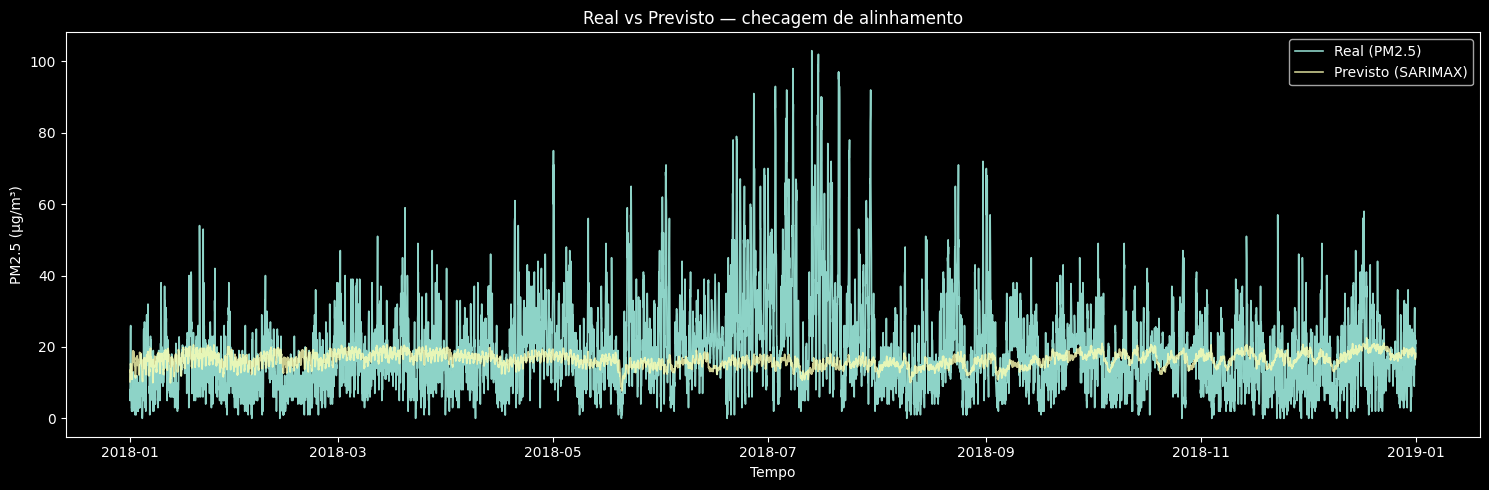

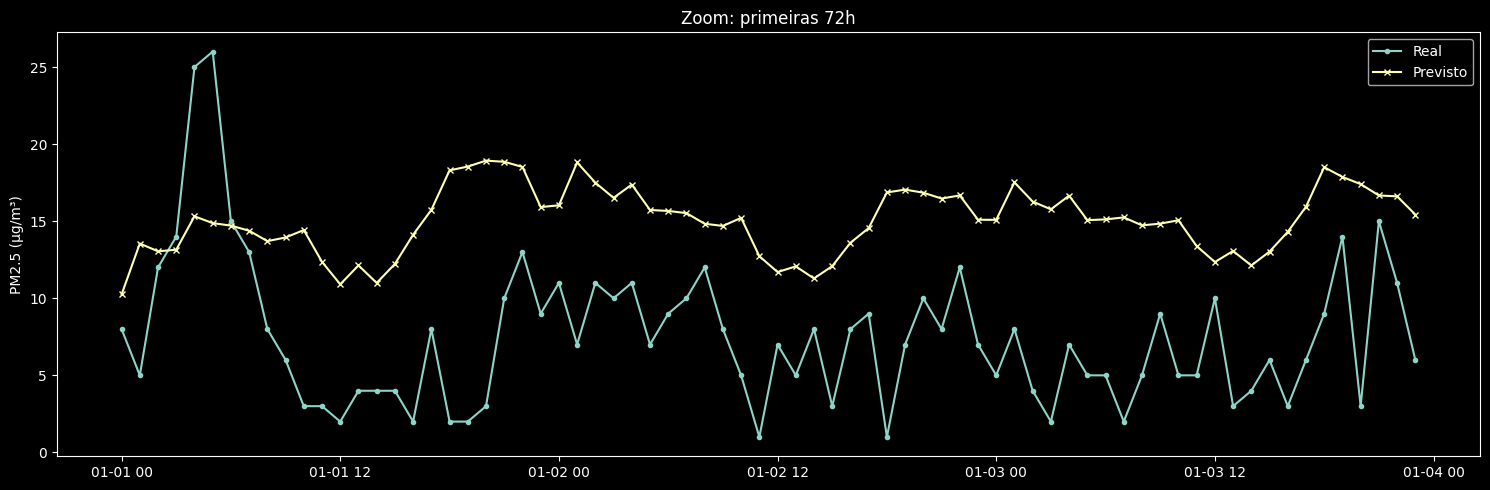

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fc = model_final.get_forecast(steps=len(y_val), exog=X_val)
y_pred = fc.predicted_mean

y_real = y_val


print("Shape y_real:", y_real.shape, "| Shape y_pred:", y_pred.shape)
print("y_real:", y_real.index[0], "->", y_real.index[-1])
print("y_pred:", y_pred.index[0], "->", y_pred.index[-1])

print("Índices iguais?", y_real.index.equals(y_pred.index))


print("TZ real:", y_real.index.tz, "| TZ pred:", y_pred.index.tz)


df = pd.concat([y_real.rename("real"), y_pred.rename("pred")], axis=1)
print("Linhas após alinhar:", len(df), "| com NaN:", df.isna().any(axis=1).sum())

df_clean = df.dropna()
for shift in [-2, -1, 0, 1, 2]:
    corr = df_clean["real"].corr(df_clean["pred"].shift(shift))
    flag = "  <-- maior" if shift != 0 else "  (sem shift)"
    print(f"shift {shift:+d}: corr = {corr:.4f}{flag if shift==0 else ''}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_clean.index, df_clean["real"], label="Real (PM2.5)", linewidth=1.2)
ax.plot(df_clean.index, df_clean["pred"], label="Previsto (SARIMAX)",
        linewidth=1.2, alpha=0.8)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Tempo")
ax.set_title("Real vs Previsto — checagem de alinhamento")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
janela = df_clean.iloc[:72]
ax.plot(janela.index, janela["real"], marker="o", markersize=3, label="Real")
ax.plot(janela.index, janela["pred"], marker="x", markersize=4, label="Previsto")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Zoom: primeiras 72h")
ax.legend()
plt.tight_layout()
plt.show()

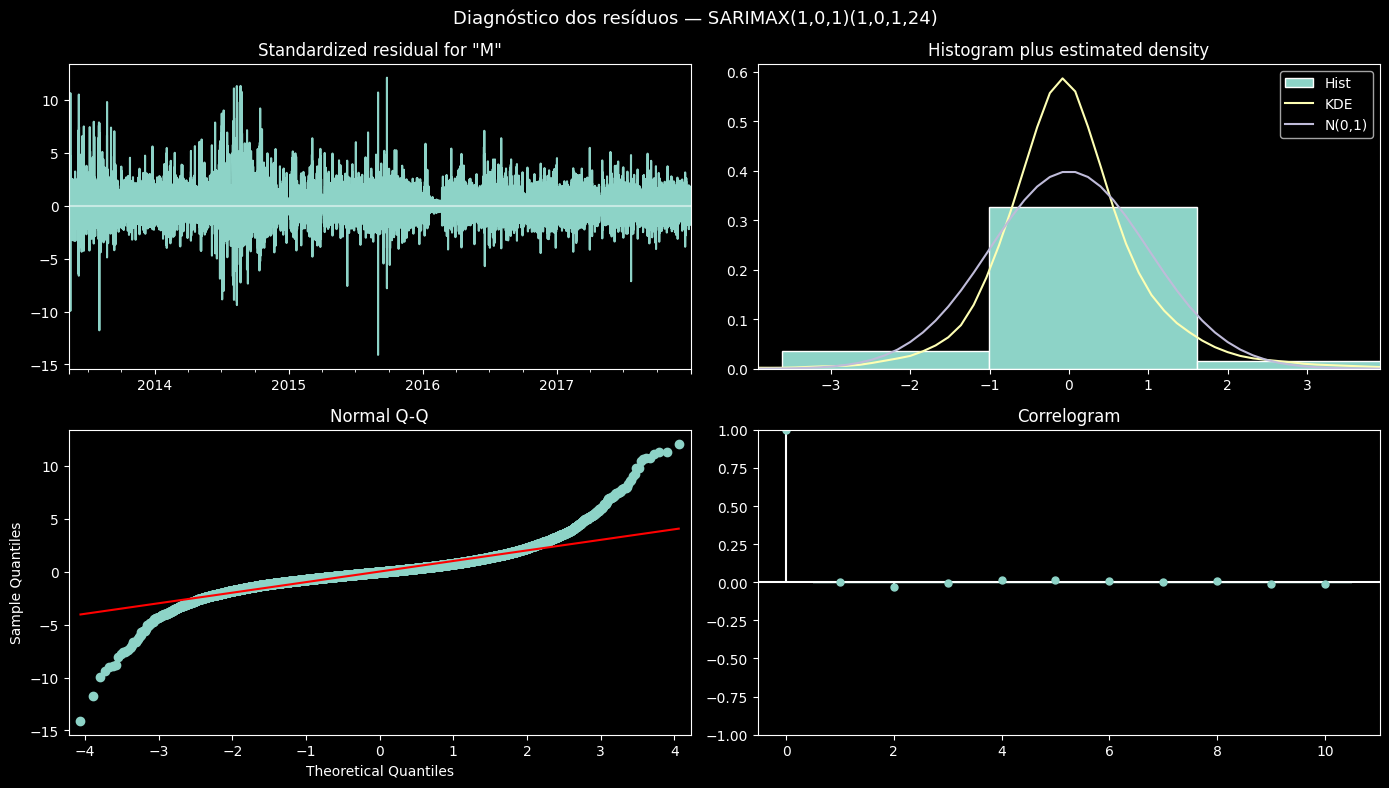

In [72]:
fig = model_final.plot_diagnostics(figsize=(14, 8))
fig.suptitle('Diagnóstico dos resíduos — SARIMAX(1,0,1)(1,0,1,24)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Avaliação — Validação (2018)

In [83]:
from sklearn.metrics import r2_score

def avaliar(y_real, y_pred, label=''):
    idx = y_real.index.intersection(y_pred.index)
    y_r = y_real.loc[idx]
    y_p = y_pred.loc[idx]

    mae  = mean_absolute_error(y_r, y_p)
    rmse = np.sqrt(mean_squared_error(y_r, y_p))
    r2   = r2_score(y_r, y_p)

    print(f'\n── Métricas: {label} ────────────────────')
    print(f'  MAE  : {mae:.3f} µg/m³')
    print(f'  RMSE : {rmse:.3f} µg/m³')
    print(f'  R²   : {r2:.4f}')
    return {'set': label, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

## 9. Avaliação — Validação (2018)

In [84]:
# 1-step ahead
pred_val = model_final.get_prediction(
    start=y_val.index[0],
    end=y_val.index[-1],
    exog=X_val,
    dynamic=False
)
pred_val_mean = pred_val.predicted_mean
pred_val_ci   = pred_val.conf_int(alpha=0.05)

metrics_val = avaliar(y_val, pred_val_mean, 'Validação 2018 (1-step)')


── Métricas: Validação 2018 (1-step) ────────────────────
  MAE  : 8.477 µg/m³
  RMSE : 12.809 µg/m³
  R²   : -0.0256


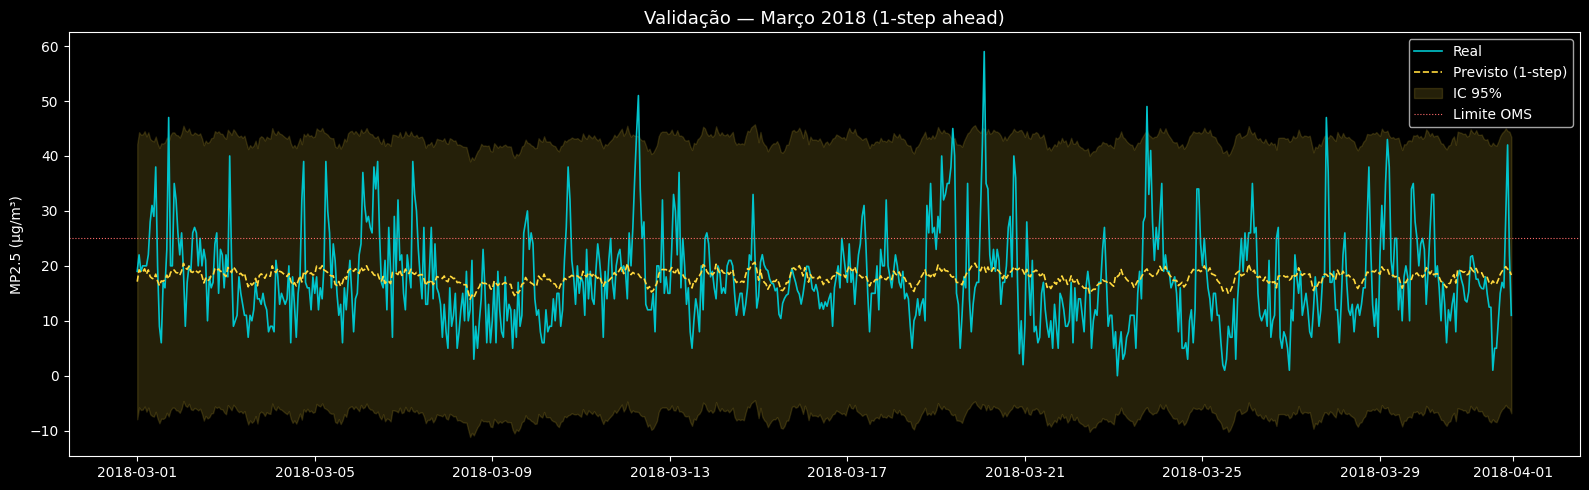

In [85]:
# Plot — Março 2018
window = slice('2018-03-01', '2018-03-31')
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(y_val[window].index, y_val[window],
        color=ACCENT, linewidth=1.2, label='Real')
ax.plot(pred_val_mean[window].index, pred_val_mean[window],
        color=ACCENT3, linewidth=1.2, linestyle='--', label='Previsto (1-step)')
ax.fill_between(
    pred_val_ci.loc[window].index,
    pred_val_ci.iloc[:, 0].loc[window],
    pred_val_ci.iloc[:, 1].loc[window],
    color=ACCENT3, alpha=0.15, label='IC 95%'
)
ax.axhline(25, color=ACCENT2, linestyle=':', linewidth=0.8, label='Limite OMS')
ax.set_title('Validação — Março 2018 (1-step ahead)', fontsize=13)
ax.set_ylabel('MP2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

In [86]:
# Multi-step (dynamic=True)
pred_val_dyn = model_final.get_prediction(
    start=y_val.index[0],
    end=y_val.index[-1],
    exog=X_val,
    dynamic=True
)
metrics_val_dyn = avaliar(y_val, pred_val_dyn.predicted_mean, 'Validação 2018 (multi-step)')


── Métricas: Validação 2018 (multi-step) ────────────────────
  MAE  : 8.477 µg/m³
  RMSE : 12.809 µg/m³
  R²   : -0.0256


## 10. Avaliação Final — Teste (jan–ago 2019)

In [87]:
# get_forecast para dados fora do período de treino (out-of-sample)
pred_test = model_final.get_forecast(
    steps=len(y_test),
    exog=X_test
)
pred_test_mean = pred_test.predicted_mean
pred_test_ci   = pred_test.conf_int(alpha=0.05)

pred_test_mean.index = y_test.index
pred_test_ci.index   = y_test.index

metrics_test = avaliar(y_test, pred_test_mean, 'Teste 2019 (1-step)')


── Métricas: Teste 2019 (1-step) ────────────────────
  MAE  : 8.952 µg/m³
  RMSE : 13.132 µg/m³
  R²   : -0.0367


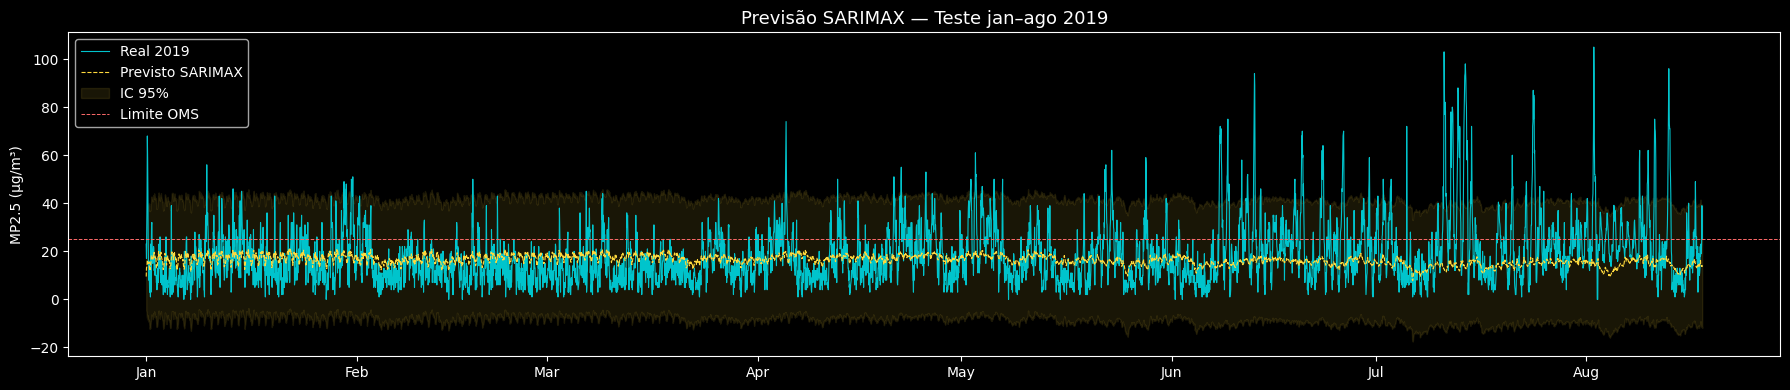

In [88]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(y_test.index, y_test, color=ACCENT, linewidth=0.8, label='Real 2019')
ax.plot(pred_test_mean.index, pred_test_mean,
        color=ACCENT3, linewidth=0.8, linestyle='--', label='Previsto SARIMAX')
ax.fill_between(
    pred_test_ci.index,
    pred_test_ci.iloc[:, 0],
    pred_test_ci.iloc[:, 1],
    color=ACCENT3, alpha=0.1, label='IC 95%'
)
ax.axhline(25, color=ACCENT2, linestyle='--', linewidth=0.7, label='Limite OMS')
ax.set_title('Previsão SARIMAX — Teste jan–ago 2019', fontsize=13)
ax.set_ylabel('MP2.5 (µg/m³)')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend()
plt.tight_layout()
plt.show()

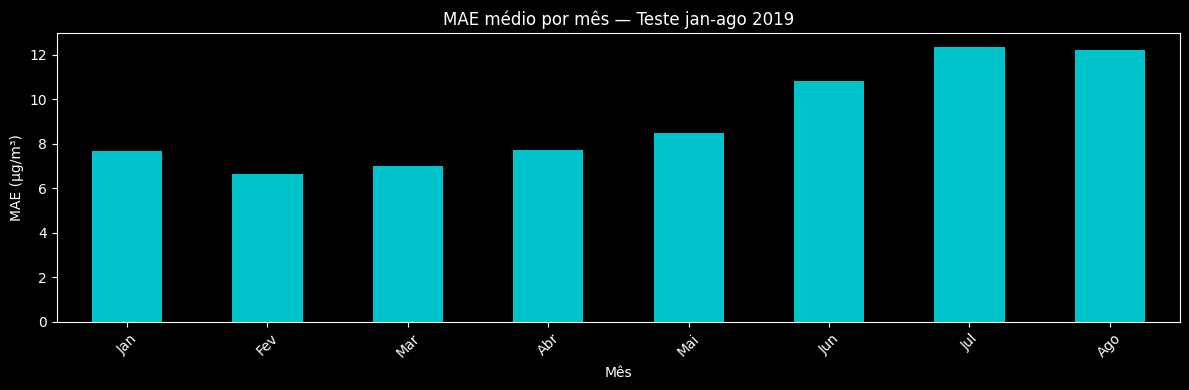

In [89]:
idx_comun = y_test.index.intersection(pred_test_mean.index)
erros = pd.DataFrame({
    'real'    : y_test.loc[idx_comun],
    'previsto': pred_test_mean.loc[idx_comun]
})
erros['erro_abs'] = (erros['real'] - erros['previsto']).abs()
erros['mes'] = erros.index.month

fig, ax = plt.subplots(figsize=(12, 4))
erros.groupby('mes')['erro_abs'].mean().plot(kind='bar', color=ACCENT, ax=ax)
ax.set_title('MAE médio por mês — Teste jan-ago 2019')
ax.set_xlabel('Mês')
ax.set_ylabel('MAE (µg/m³)')
meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
meses_presentes = erros['mes'].unique()
ax.set_xticklabels([meses_nomes[m-1] for m in sorted(meses_presentes)], rotation=45)
plt.tight_layout()
plt.show()

## 11. Métricas Consolidadas e Conclusões

In [91]:
df_metrics = pd.DataFrame([metrics_val, metrics_val_dyn, metrics_test])
df_metrics['MAE']  = df_metrics['MAE'].round(3)
df_metrics['RMSE'] = df_metrics['RMSE'].round(3)
df_metrics['R2']   = df_metrics['R2'].round(4)

print('\n📊 TABELA DE MÉTRICAS CONSOLIDADA')
print('=' * 65)
print(df_metrics[['set','MAE','RMSE','R2']].to_string(index=False))
print('=' * 65)
print(f'\nModelo : SARIMAX(1,0,1)(1,0,1,24)')
print(f'Exog   : {EXOG_COLS}')
print(f'Treino : 2013-2017  |  Validação : 2018  |  Teste : jan-ago 2019')


📊 TABELA DE MÉTRICAS CONSOLIDADA
                        set   MAE   RMSE      R2
    Validação 2018 (1-step) 8.477 12.809 -0.0256
Validação 2018 (multi-step) 8.477 12.809 -0.0256
        Teste 2019 (1-step) 8.952 13.132 -0.0367

Modelo : SARIMAX(1,0,1)(1,0,1,24)
Exog   : ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']
Treino : 2013-2017  |  Validação : 2018  |  Teste : jan-ago 2019


In [92]:
os.makedirs('../reports', exist_ok=True)
df_metrics.to_csv('../reports/metricas_sarimax_2013_2019.csv', index=False)
print('✅ Métricas → ../reports/metricas_sarimax_2013_2019.csv')

✅ Métricas → ../reports/metricas_sarimax_2013_2019.csv


In [93]:
import json

params = {
    'order'         : (1, 0, 1),
    'seasonal_order': (1, 0, 1, 24),
    'params'        : model_final.params.to_dict()
}

os.makedirs('../models', exist_ok=True)
with open('../models/sarimax_params_2013_2019.json', 'w') as f:
    json.dump(params, f, indent=2)

print('✅ Parâmetros → ../models/sarimax_params_2013_2019.json')

✅ Parâmetros → ../models/sarimax_params_2013_2019.json
